# Env code

In [1]:
import kaggle_environments as ke

[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO: Successfully loaded OpenSpiel environments: 17.
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_amazons
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_backgammon
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_checkers
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_chess
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_connect_four
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_dark_hex
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_gin_rummy
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_go
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_goofspiel
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_hearts
[kaggle_environments.envs.open_sp

In [2]:
from collections import namedtuple
import math

# Named tuples for agent convenience.
# Planets and fleets share a common [id, owner, x, y, ...] prefix.
Planet = namedtuple(
    "Planet", ["id", "owner", "x", "y", "radius", "ships", "production"]
)
Fleet = namedtuple(
    "Fleet", ["id", "owner", "x", "y", "angle", "from_planet_id", "ships"]
)

# Constants
BOARD_SIZE = 100.0
CENTER = BOARD_SIZE / 2.0
SUN_RADIUS = 10.0
ROTATION_RADIUS_LIMIT = 50.0
COMET_RADIUS = 1.0
COMET_PRODUCTION = 1
PLANET_CLEARANCE = 7
MIN_PLANET_GROUPS = 5
MAX_PLANET_GROUPS = 10
MIN_STATIC_GROUPS = 3
COMET_SPAWN_STEPS = [50, 150, 250, 350, 450]
PLANET_MARGIN = 0.1

CENTER_X = 50.0
CENTER_Y = 50.0
MAX_SPEED = 6.0
MAX_NB_STEP = 500


def distance(p1, p2):
    return math.sqrt((p1[0] - p2[0]) ** 2 + (p1[1] - p2[1]) ** 2)


def point_to_segment_distance(p, v, w):
    """Minimum distance from point p to line segment v-w."""
    l2 = (v[0] - w[0]) ** 2 + (v[1] - w[1]) ** 2
    if l2 == 0.0:
        return distance(p, v)
    t = max(
        0, min(1, ((p[0] - v[0]) * (w[0] - v[0]) + (p[1] - v[1]) * (w[1] - v[1])) / l2)
    )
    projection = (v[0] + t * (w[0] - v[0]), v[1] + t * (w[1] - v[1]))
    return distance(p, projection)

def interpreter(obs, actions, step, num_agents=2):
    # configuration = env.configuration
    obs0 = obs

    # Remove expired comets before fleet launch so agents can't act on them
    expired_comet_pids = []
    for group in obs0.comets:
        idx = group["path_index"]
        for i, pid in enumerate(group["planet_ids"]):
            if idx >= len(group["paths"][i]):
                expired_comet_pids.append(pid)
    if expired_comet_pids:
        expired_set = set(expired_comet_pids)
        obs0.planets = [p for p in obs0.planets if p[0] not in expired_set]
        obs0.initial_planets = [
            p for p in obs0.initial_planets if p[0] not in expired_set
        ]
        obs0.comet_planet_ids = [
            pid for pid in obs0.comet_planet_ids if pid not in expired_set
        ]
        for group in obs0.comets:
            group["planet_ids"] = [
                pid for pid in group["planet_ids"] if pid not in expired_set
            ]
        obs0.comets = [g for g in obs0.comets if g["planet_ids"]]

    # Spawn extra-solar comets at designated steps
    # step = get(obs0, "step", 0)
    # comet_speed = configuration.cometSpeed
    # if (step + 1) in COMET_SPAWN_STEPS:
    #     # Derive a per-spawn RNG from the episode seed so comet shape and
    #     # ship counts are reproducible. Seed lives on env.info to keep it
    #     # hidden from agents (see init block above).
    #     env_info = getattr(env, "info", None) or {}
    #     episode_seed = env_info.get("seed", 0) or 0
    #     comet_rng = random.Random(f"orbit_wars-comet-{episode_seed}-{step + 1}")
    #     comet_paths = generate_comet_paths(
    #         obs0.initial_planets,
    #         obs0.angular_velocity,
    #         step + 1,
    #         obs0.comet_planet_ids,
    #         comet_speed,
    #         rng=comet_rng,
    #     )
    #     if comet_paths:
    #         next_id = max(p[0] for p in obs0.planets) + 1
    #         comet_ships = min(
    #             comet_rng.randint(1, 99),
    #             comet_rng.randint(1, 99),
    #             comet_rng.randint(1, 99),
    #             comet_rng.randint(1, 99),
    #         )
    #         group = {"planet_ids": [], "paths": comet_paths, "path_index": -1}
    #         for i, p_path in enumerate(comet_paths):
    #             pid = next_id + i
    #             group["planet_ids"].append(pid)
    #             obs0.comet_planet_ids.append(pid)
    #             # Start off-board; first advancement will place at path[0]
    #             planet = [
    #                 pid,
    #                 -1,
    #                 -99,
    #                 -99,
    #                 COMET_RADIUS,
    #                 comet_ships,
    #                 COMET_PRODUCTION,
    #             ]
    #             obs0.planets.append(planet)
    #             obs0.initial_planets.append(planet[:])
    #         obs0.comets.append(group)

    # 0. Fleet Launch
    def process_moves(player_id, action):
        if not action or not isinstance(action, list):
            return
        for move in action:
            if len(move) != 3:
                continue
            from_id, angle, ships = move
            ships = int(ships)  # Sanitize to integer

            from_planet = next((p for p in obs0.planets if p[0] == from_id), None)

            if from_planet and from_planet[1] == player_id:
                if from_planet[5] >= ships and ships > 0:
                    from_planet[5] -= ships
                    # Start fleet just outside the planet so it doesn't
                    # immediately collide with its origin.
                    start_x = from_planet[2] + math.cos(angle) * (from_planet[4] + 0.1)
                    start_y = from_planet[3] + math.sin(angle) * (from_planet[4] + 0.1)
                    obs0.fleets.append(
                        [
                            obs0.next_fleet_id,
                            player_id,
                            start_x,
                            start_y,
                            angle,
                            from_id,
                            ships,
                        ]
                    )
                    obs0.next_fleet_id += 1

    for i in range(num_agents):
        process_moves(i, actions[i])

    # 1. Production
    for planet in obs0.planets:
        if planet[1] != -1:
            planet[5] += planet[6]

    # 2. Fleet Movement (with continuous collision detection)
    # Speed scales with fleet size: 1 ship = 1/turn, max = shipSpeed (default 6)
    max_speed = MAX_SPEED
    fleets_to_remove = []
    combat_lists = {p[0]: [] for p in obs0.planets}

    for fleet in obs0.fleets:
        angle = fleet[4]
        ships = fleet[6]
        speed = 1.0 + (max_speed - 1.0) * (math.log(ships) / math.log(1000)) ** 1.5
        speed = min(speed, max_speed)
        old_pos = (fleet[2], fleet[3])
        fleet[2] += math.cos(angle) * speed
        fleet[3] += math.sin(angle) * speed
        new_pos = (fleet[2], fleet[3])

        # Check if fleet path intersected any planet (continuous collision).
        # Check planets first so fast fleets that would overshoot the bounds
        # or sun still get credit for hitting a planet along the way.
        hit_planet = False
        for planet in obs0.planets:
            planet_pos = (planet[2], planet[3])
            if point_to_segment_distance(planet_pos, old_pos, new_pos) < planet[4]:
                combat_lists[planet[0]].append(fleet)
                fleets_to_remove.append(fleet)
                hit_planet = True
                break
        if hit_planet:
            continue

        # Check if fleet went out of bounds
        if not (0 <= fleet[2] <= BOARD_SIZE and 0 <= fleet[3] <= BOARD_SIZE):
            fleets_to_remove.append(fleet)
            continue

        # Check if fleet path crossed the sun
        if point_to_segment_distance((CENTER, CENTER), old_pos, new_pos) < SUN_RADIUS:
            fleets_to_remove.append(fleet)
            continue

    # 3. Planet Movement & Sweep
    angular_velocity = obs0.angular_velocity
    comet_pid_set = set(obs0.comet_planet_ids)
    initial_by_id = {p[0]: p for p in obs0.initial_planets}

    def sweep_fleets(planet, old_pos, new_pos):
        """Check if any fleet is caught by a planet moving from old to new."""
        if old_pos == new_pos:
            return
        for fleet in obs0.fleets:
            if fleet not in fleets_to_remove:
                if (
                    point_to_segment_distance((fleet[2], fleet[3]), old_pos, new_pos)
                    < planet[4]
                ):
                    combat_lists[planet[0]].append(fleet)
                    fleets_to_remove.append(fleet)

    # Regular planet rotation
    for planet in obs0.planets:
        if planet[0] in comet_pid_set:
            continue
        initial_p = initial_by_id.get(planet[0])
        if not initial_p:
            continue
        dx = initial_p[2] - CENTER
        dy = initial_p[3] - CENTER
        r = math.sqrt(dx**2 + dy**2)
        old_pos = (planet[2], planet[3])

        if r + planet[4] < ROTATION_RADIUS_LIMIT:
            initial_angle = math.atan2(dy, dx)
            current_angle = initial_angle + angular_velocity * step
            planet[2] = CENTER + r * math.cos(current_angle)
            planet[3] = CENTER + r * math.sin(current_angle)

        sweep_fleets(planet, old_pos, (planet[2], planet[3]))

    # Comet movement along pre-computed paths
    expired_comet_pids = []
    for group in obs0.comets:
        group["path_index"] += 1
        idx = group["path_index"]
        for i, pid in enumerate(group["planet_ids"]):
            planet = next((p for p in obs0.planets if p[0] == pid), None)
            if planet is None:
                continue
            p_path = group["paths"][i]
            if idx >= len(p_path):
                expired_comet_pids.append(pid)
            else:
                old_pos = (planet[2], planet[3])
                planet[2] = p_path[idx][0]
                planet[3] = p_path[idx][1]
                # Skip sweep on first placement (old_pos is off-board placeholder)
                if old_pos[0] >= 0:
                    sweep_fleets(planet, old_pos, (planet[2], planet[3]))

    # Remove expired comets immediately
    if expired_comet_pids:
        expired_set = set(expired_comet_pids)
        obs0.planets = [p for p in obs0.planets if p[0] not in expired_set]
        obs0.initial_planets = [
            p for p in obs0.initial_planets if p[0] not in expired_set
        ]
        obs0.comet_planet_ids = [
            pid for pid in obs0.comet_planet_ids if pid not in expired_set
        ]
        for group in obs0.comets:
            group["planet_ids"] = [
                pid for pid in group["planet_ids"] if pid not in expired_set
            ]
        obs0.comets = [g for g in obs0.comets if g["planet_ids"]]

    obs0.fleets = [f for f in obs0.fleets if f not in fleets_to_remove]

    # 4. Combat Resolution
    for pid, planet_fleets in combat_lists.items():
        planet = next((p for p in obs0.planets if p[0] == pid), None)
        if not planet or not planet_fleets:
            continue

        # Sum ships per player
        player_ships = {}
        for fleet in planet_fleets:
            owner = fleet[1]
            player_ships[owner] = player_ships.get(owner, 0) + fleet[6]

        if not player_ships:
            continue

        sorted_players = sorted(
            player_ships.items(), key=lambda item: item[1], reverse=True
        )
        top_player, top_ships = sorted_players[0]

        if len(sorted_players) > 1:
            second_ships = sorted_players[1][1]
            survivor_ships = top_ships - second_ships

            if sorted_players[0][1] == sorted_players[1][1]:
                survivor_ships = 0

            survivor_owner = top_player if survivor_ships > 0 else -1
        else:
            survivor_owner = top_player
            survivor_ships = top_ships

        if survivor_ships > 0:
            if planet[1] == survivor_owner:
                planet[5] += survivor_ships
            else:
                planet[5] -= survivor_ships
                if planet[5] < 0:
                    planet[1] = survivor_owner
                    planet[5] = abs(planet[5])

    obs1 = {}
    obs1["planets"] = obs0.planets
    obs1["initial_planets"] = obs0.initial_planets
    obs1["fleets"] = obs0.fleets
    obs1["next_fleet_id"] = obs0.next_fleet_id
    obs1["comets"] = obs0.comets
    obs1["comet_planet_ids"] = obs0.comet_planet_ids

    terminated = False
    if step >= MAX_NB_STEP - 2:
        terminated = True

    alive_players = set()
    for p in obs0.planets:
        if p[1] != -1:
            alive_players.add(p[1])
    for f in obs0.fleets:
        alive_players.add(f[1])

    if len(alive_players) <= 1:
        terminated = True


    return obs1

# Test cases

## Helpers

In [3]:
import copy, math
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# ── Constants ─────────────────────────────────────────────────────────────────
CENTER = 50.0
SUN_RADIUS = 10.0
ROTATION_RADIUS_LIMIT = 50.0
MAX_SPEED = 6.0
NB_STEPS_SIM = 20
# ---------------------------------------------------------------------------
# Minimal obs object compatible with the interpreter
# ---------------------------------------------------------------------------
class Obs:
    def __init__(self, planets, initial_planets=None, fleets=None,
                 next_fleet_id=100, comets=None, comet_planet_ids=None,
                 angular_velocity=0.0):
        self.planets          = [list(p) for p in planets]
        self.initial_planets  = [list(p) for p in (initial_planets if initial_planets is not None else planets)]
        self.fleets           = [list(f) for f in (fleets or [])]
        self.next_fleet_id    = next_fleet_id
        self.comets           = comets or []
        self.comet_planet_ids = comet_planet_ids or []
        self.angular_velocity = angular_velocity


# Owner -> colour
_COLORS = {0: 'steelblue', 1: 'tomato', -1: '#888888'}


def simulate(obs, n_steps, current_step=0):
    """Step the interpreter n times; return a snapshot list."""
    snapshots = []
    for step in range(current_step, current_step + n_steps):
        snapshots.append({
            'step':    step,
            'planets': [p[:] for p in obs.planets],
            'fleets':  [f[:] for f in obs.fleets],
        })
        interpreter(obs, [[], []], step)
    return snapshots

def simulate_with_action(obs, action0, n_steps, current_step=0):
    """Like simulate() but applies action0 on step 0 only."""
    snapshots = []
    for i, step in enumerate(range(current_step, current_step + n_steps)):
        snapshots.append({
            'step':    step,
            'planets': [p[:] for p in obs.planets],
            'fleets':  [f[:] for f in obs.fleets],
        })
        interpreter(obs, [action0 if i == 0 else [], []], step)
    return snapshots


def _simulate(obs, global_step, num_agents, n_steps=NB_STEPS_SIM):
    sim = copy.deepcopy(obs)
    no_actions = [[] for _ in range(num_agents)]
    rows = []
    for i in range(n_steps+1):
        for p in sim.planets:
            pid, owner, x, y, radius, ships, production = (
                p[0], p[1], p[2], p[3], p[4], p[5], p[6]
            )
            r = math.hypot(x - CENTER, y - CENTER)
            if pid in sim.comet_planet_ids:
                nature = "comet"
            elif r + radius < ROTATION_RADIUS_LIMIT:
                nature = "moving"
            else:
                nature = "fix"
            rows.append({
                "step": global_step + i,
                "id": pid,
                "x": x,
                "y": y,
                "radius": radius,
                "ships": ships,
                "production": production,
                "owner": owner,
                "nature": nature,
            })
        interpreter(sim, no_actions, global_step + i, num_agents)
    return pd.DataFrame(rows)


def make_animation(snapshots, title='', interval=150):
    """Animate a snapshot list produced by simulate()."""
    fig, ax = plt.subplots(figsize=(6, 6))
    fig.patch.set_facecolor('#111122')

    def draw(frame):
        snap = snapshots[frame]
        ax.cla()
        ax.set_xlim(0, 100)
        ax.set_ylim(100, 0)   # y decreases downward: 100 at top, 0 at bottom
        ax.set_aspect('equal')
        ax.set_facecolor('#111122')
        ax.tick_params(colors='#aaaaaa')
        for sp in ax.spines.values():
            sp.set_edgecolor('#444444')
        ax.set_title(f"{title}  (step {snap['step']})", color='white', fontsize=11)

        # Sun
        ax.add_patch(plt.Circle((50, 50), 10, color='gold', zorder=2, alpha=0.9))

        # Planets
        for p in snap['planets']:
            pid, owner, x, y, radius, ships, production = p
            c = _COLORS.get(owner, '#888888')
            ax.add_patch(plt.Circle((x, y), radius, color=c, alpha=0.85, zorder=3))
            ax.text(x, y, str(ships),
                    ha='center', va='center', color='white',
                    fontsize=7, fontweight='bold', zorder=4)
            ax.text(x, y+2, str(pid),
                    ha='center', va='center', color='red',
                    fontsize=7, fontweight='bold', zorder=4)
            ax.text(x, y-2, "+"+str(production),
                    ha='center', va='center', color='green',
                    fontsize=7, fontweight='bold', zorder=4)

        # Fleets
        for f in snap['fleets']:
            fid, owner, x, y, angle, from_id, ships = f
            c = _COLORS.get(owner, '#888888')
            ax.plot(x, y, 'D', color=c, markersize=5, zorder=5)
            ax.text(x + 1.5, y + 1.5, str(ships), color=c, fontsize=5, zorder=6)

        return []

    ani = animation.FuncAnimation(fig, draw, frames=len(snapshots), interval=interval)
    plt.close()
    return HTML(ani.to_jshtml())


def print_df(df):
    print(df)
    return df

## Interval

In [4]:
import numpy as np

class IntervalProcessor:
    def merge_intervals(intervals):
        """Merges a list of [min, max] angle intervals where min <= max."""
        if not intervals:
            return []

        # Sort intervals by their start angle
        intervals = sorted(intervals, key=lambda x: x[0])
        merged = [intervals[0]]

        for current in intervals[1:]:
            prev_min, prev_max = merged[-1]
            curr_min, curr_max = current

            # If current interval overlaps with or touches the previous one
            if curr_min <= prev_max:
                merged[-1] = (prev_min, max(prev_max, curr_max))
            else:
                merged.append(current)

        return merged


    def create_cumulative_obstacles(possible_attacks, min_step=0):
        # 1. Determine the maximum step in the entire dataset
        max_step = int(possible_attacks["step"].max())

        # 2. Extract and unwrap intervals per (id_src, ships_sent, step) combination
        attack_map = {}
        group_cols = ["id_src", "ships_sent", "step"]

        for (id_src, ship, step), group in possible_attacks.groupby(group_cols):
            unwrapped_intervals = []

            for _, row in group.iterrows():
                amin, amax = row["angle_min"], row["angle_max"]

                if amin > amax:
                    # Modulo overlap caught: Split into two valid intervals
                    unwrapped_intervals.append((amin, 2 * np.pi))
                    unwrapped_intervals.append((0.0, amax))
                else:
                    # Normal interval
                    unwrapped_intervals.append((amin, amax))

            # Store using a triple-compound key (id_src, ship, step)
            attack_map[(id_src, ship, step)] = unwrapped_intervals

        # 3. Get all unique combinations of id_src and ships_sent to build continuous timelines
        unique_combinations = (
            possible_attacks[["id_src", "ships_sent"]].drop_duplicates().values
        )

        cumulative_records = []

        # Loop through each independent identifier track
        for id_src, ship in unique_combinations:
            current_intervals = []
            merged = []

            # Run the sequential simulation loop from min_step up to max_step (inclusive)
            for step in range(min_step, max_step + 1):

                # Accumulate new obstacles if they exist for this specific path
                if (id_src, ship, step) in attack_map:
                    current_intervals.extend(attack_map[(id_src, ship, step)])
                    # Merge everything tracked up to this point
                    merged = IntervalProcessor.merge_intervals(current_intervals)

                # Append the record maintaining your step shifting format
                cumulative_records.append(
                    {
                        "step": step + 1,
                        "id_src": id_src,
                        "ships_sent": ship,
                        "obstacle_list": merged,
                    }
                )

        return pd.DataFrame(cumulative_records)
    

    def subtract_intervals(target_min, target_max, blocked_intervals):
        """Subtracts a list of blocked intervals from a single valid [min, max] target interval."""
        # We start assuming the entire target interval is free/safe
        safe_intervals = [(target_min, target_max)]

        for b_min, b_max in blocked_intervals:
            next_safe = []
            for s_min, s_max in safe_intervals:
                # Case 1: Blocked interval completely misses the safe interval
                if b_max <= s_min or b_min >= s_max:
                    next_safe.append((s_min, s_max))

                # Case 2: Blocked interval overlaps or cuts into the safe interval
                else:
                    # Keep left piece if it exists
                    if b_min > s_min:
                        next_safe.append((s_min, b_min))
                    # Keep right piece if it exists
                    if b_max < s_max:
                        next_safe.append((b_max, s_max))

            safe_intervals = next_safe
            if not safe_intervals:
                break

        return safe_intervals


    def compute_free_angles(row):
        """Processes a single row to handle modulo wrapping and find the difference."""
        amin = row["angle_min"]
        amax = row["angle_max"]
        obstacles = row["obstacle_list"]

        # If there are no obstacles, the entire target interval is completely free
        if not isinstance(obstacles, list) or len(obstacles) == 0:
            return [(amin, amax)]

        # 1. Handle wrapping: Split target interval if it crosses the 2*pi boundary
        if amin > amax:
            targets = [(amin, 2 * np.pi), (0.0, amax)]
        else:
            targets = [(amin, amax)]

        # 2. Subtract obstacles from all active targets
        all_free_intervals = []
        for t_min, t_max in targets:
            free_pieces = IntervalProcessor.subtract_intervals(t_min, t_max, obstacles)
            all_free_intervals.extend(free_pieces)

        # 3. Re-wrap adjacent boundary pieces if necessary
        # (If one piece ends at 2*pi and another starts at 0, they are the same interval)
        has_end_piece = any(abs(f[1] - 2 * np.pi) < 1e-9 for f in all_free_intervals)
        has_start_piece = any(abs(f[0] - 0.0) < 1e-9 for f in all_free_intervals)

        if has_end_piece and has_start_piece and len(all_free_intervals) > 1:
            # Find them
            end_idx = next(
                i
                for i, f in enumerate(all_free_intervals)
                if abs(f[1] - 2 * np.pi) < 1e-9
            )
            start_idx = next(
                i for i, f in enumerate(all_free_intervals) if abs(f[0] - 0.0) < 1e-9
            )

            # Merge them back into a single modulo-wrapped interval: (min_of_end_piece, max_of_start_piece)
            wrapped_interval = (
                all_free_intervals[end_idx][0],
                all_free_intervals[start_idx][1],
            )

            # Remove old pieces and add the cleanly wrapped one
            indices_to_remove = {end_idx, start_idx}
            all_free_intervals = [
                f for i, f in enumerate(all_free_intervals) if i not in indices_to_remove
            ]
            all_free_intervals.append(wrapped_interval)

        return all_free_intervals

    def interval_to_final_angle(angle_list_series):
        """Takes a pandas Series of interval lists, finds the widest interval in each row,

        and returns its midpoint/average angle modulo 2*pi.
        """

        def process_row_intervals(intervals):
            if not isinstance(intervals, list) or len(intervals) == 0:
                return np.nan

            widest_span = -1.0
            best_midpoint = np.nan

            for amin, amax in intervals:
                # 1. Calculate the true span length considering modulo 2*pi wrap-around
                if amin <= amax:
                    span = amax - amin
                else:
                    span = (2 * np.pi - amin) + amax

                # 2. Track the maximum width seen so far
                if span > widest_span:
                    widest_span = span

                    # 3. Calculate the midpoint angle safely
                    if amin <= amax:
                        midpoint = (amin + amax) / 2.0
                    else:
                        midpoint = amin + (span / 2.0)

                    # Keep the final angle bound strictly between 0 and 2*pi
                    best_midpoint = midpoint % (2 * np.pi)

            return best_midpoint

        # Map the helper over the entire pandas Series
        return angle_list_series.map(process_row_intervals)

## Take action

In [5]:


        
def take_action(df, player_id, nb_steps_sim=NB_STEPS_SIM, return_df=False):
    mine_across_sim = (
        df
        .assign(
            is_mine=lambda d: (d["owner"]==player_id).astype(int)
        )
        # .query("owner == @player_id")
        .groupby("id")
        .agg(
            step_src=("step", "first"),
            x_src=("x", "first"),
            y_src=("y", "first"),
            radius_src=("radius", "first"),
            ships_min=("ships", "min"),
            production_src=("production", "first"),
            nature_src=("nature", "first"),
            owner_src=("owner", "first"),
            row_count=("ships", "size"),
            is_mine=("is_mine", "sum"),
        )
        # .query("row_count >= @nb_steps_sim + 1 and ships_min > 0")
        .query("row_count == is_mine and owner_src==@player_id")
        .reset_index(drop=False)
        .rename(columns={"id": "id_src"})
    )

    expanded_mine = (
        mine_across_sim
        .assign(ships_sent=(mine_across_sim["ships_min"] + mine_across_sim["production_src"] * NB_STEPS_SIM).apply(lambda n: list(range(1, n + 1))))
        .explode("ships_sent")
        .astype({"ships_sent": int})
        .reset_index(drop=True)
    )

    df_src_tgt = (
        expanded_mine
        .merge(
            df,
            how="cross"
        )
        .query("step > step_src and id != id_src")
    )

    possible_attacks = (
        df_src_tgt
        .assign(
            dist_tgt_src=lambda d: ((d["x"] - d["x_src"]) ** 2 + (d["y"] - d["y_src"]) ** 2) ** 0.5,
            step_diff=lambda d: d["step"] - d["step_src"],  # For a one ship fleet, the speed is 1 unit per step
            fleet_speed=lambda d: 1.0 + (MAX_SPEED - 1.0) * (np.log(d["ships_sent"]) / math.log(1000)) ** 1.5,
            dist_fleet_src_min=lambda d: d["step_diff"] * d["fleet_speed"] + PLANET_MARGIN + d["radius_src"],
            dist_fleet_src_max=lambda d: (d["step_diff"] + 1) * d["fleet_speed"] + PLANET_MARGIN + d["radius_src"],
            collision=lambda d: ((d["dist_tgt_src"] - d["radius"] < d["dist_fleet_src_min"]) & (d["dist_fleet_src_min"] < d["dist_tgt_src"] + d["radius"])) | ((d["dist_tgt_src"] - d["radius"] < d["dist_fleet_src_max"]) & (d["dist_fleet_src_max"] < d["dist_tgt_src"] + d["radius"])),
        )
        .query("collision") # Only consider attacks we can win with the ships we have at the source during the sim
        .assign(
            crossing_sun=lambda d: d.apply(
                lambda row: point_to_segment_distance(
                    (CENTER, CENTER),
                    (row["x_src"], row["y_src"]),
                    (row["x"], row["y"]),
                ) < SUN_RADIUS + PLANET_MARGIN,
                axis=1,
            ).astype(bool)
        )
        .query("not crossing_sun")
        .assign(
            angle=lambda d: np.arctan2(d["y"] - d["y_src"], d["x"] - d["x_src"]),
            radius_angle=lambda d: np.maximum(
                np.arccos(((d["dist_tgt_src"]**2 + d["dist_fleet_src_min"]**2 - d["radius"]**2) / (2 * d["dist_tgt_src"] * d["dist_fleet_src_min"])).clip(-1, 1)),
                np.arccos(((d["dist_tgt_src"]**2 + d["dist_fleet_src_max"]**2 - d["radius"]**2) / (2 * d["dist_tgt_src"] * d["dist_fleet_src_max"])).clip(-1, 1))
            ),
            angle_min=lambda d: np.mod(d["angle"] - d["radius_angle"], 2 * math.pi),
            angle_max=lambda d: np.mod(d["angle"] + d["radius_angle"], 2 * math.pi),
        )
        .sort_values("step", ascending=True)
    )

    if possible_attacks.empty:
        if return_df:
            return [], possible_attacks
        return []

    df_obstacles = IntervalProcessor.create_cumulative_obstacles(possible_attacks)
    
    attacks_with_angle = (
        possible_attacks
        .merge(
            df_obstacles,
            how="left",
            on=["id_src", "step", "ships_sent"],
        )
        .assign(
            angle_list=lambda d: d.apply(IntervalProcessor.compute_free_angles, axis=1)
        )
        .query("angle_list.str.len() > 0")  # Only keep rows where there is at least some free angle
    )

    planet_id_top_5_id_src = (
        attacks_with_angle
        .sort_values(["step", "ships_sent"], ascending=True)
        .groupby(["id_src", "id"], as_index=False)
        .first()
        .sort_values(["step", "ships_sent"], ascending=True)
        .groupby("id_src", as_index=False)
        .head(5)
        [["id_src", "id"]]
    )

    # Comets handling
    attacks_with_angle_comets = attacks_with_angle.query("nature_src == 'comet'")
    moves = []
    if not attacks_with_angle_comets.empty and max(max((attacks_with_angle_comets["x_src"]-CENTER).abs()), max((attacks_with_angle_comets["y_src"]-CENTER).abs())) > 45:
        moves += (
            attacks_with_angle_comets
            .query("ships_sent <= ships_min")  # Ensure we have enough ships to attack
            .sort_values(["ships_sent", "step"], ascending=[False, True])
            .groupby("id_src", as_index=False)
            .first()
            [["id_src", "angle", "ships_sent"]]
            .values
            .tolist()
        )
        id_to_avoid = attacks_with_angle_comets["id_src"].unique().tolist() 
        attacks_with_angle = attacks_with_angle.query("id_src not in @id_to_avoid")  # Remove the comet attack source from the main attack dataframe to avoid double attacking from it
        

    attacks = (
        planet_id_top_5_id_src
        # Nearest top 5
        .merge(
            attacks_with_angle,
            how="left",
            on=["id_src", "id"]
        )
        # Non-player filtering
        .query("@player_id != owner")
        # ships_needed filtering
        .assign(
            ships_needed = lambda d: np.where(
                d["owner"] == -1,
                d["ships"],
                d["ships"] + d["production"]
            )
        )
        .query("ships_needed + 1 <= ships_sent and ships_sent <= ships_needed + production_src + 1")  # Ensure we are looking at future steps CAN BE LATER REMOVED TO CONSIDER PAIR ATTACKS
        .sort_values(["step", "ships_sent"], ascending=True)
        .groupby(["id_src", "id"], as_index=False)
        .first()
        # Score aiming sorted
        .assign(
            time_cost=lambda d: d["ships_needed"] / d["production_src"],
            total_time_cost=lambda d: d.groupby("id_src")["time_cost"].transform("sum"),
            score=lambda d: (d["total_time_cost"] - d["time_cost"] - d["step_diff"]) * d["production"],
        )
        .sort_values("score", ascending=False)
        .groupby("id_src", as_index=False)
        .first()
        .query("ships_sent <= ships_min")  # Ensure we have enough ships to attack
        .assign(
            final_angle = lambda d: IntervalProcessor.interval_to_final_angle(d["angle_list"])
        )
    )
    for row in attacks.itertuples():
        print(f"From {row.id_src}, To {row.id} at step {row.step} with {row.ships_sent} ships (target has min {row.ships_min})")
    moves += (
        attacks
        [["id_src", "final_angle", "ships_sent"]]
        .values
        .tolist()
    )
    if return_df:
        return moves, possible_attacks
    return moves #, attacks_with_angle, df_src_tgt

## Test 1 — Planet production
One static planet with `production=3`. Ships should increase by 3 every step.

In [6]:
# planet: id=0, owner=0, x=10, y=10, radius=5, ships=1, production=3
obs1 = Obs(
    planets=[[0, 0, 10.0, 10.0, 5.0, 1, 3]],
    angular_velocity=0.0,
)
df = _simulate(obs1, global_step=0, num_agents=2, n_steps=NB_STEPS_SIM)
print(df)
snaps1 = simulate(obs1, 10, current_step=0)
make_animation(snaps1, title='Test 1 — Planet Production (prod=3)', interval=400)

    step  id     x     y  radius  ships  production  owner nature
0      0   0  10.0  10.0     5.0      1           3      0    fix
1      1   0  10.0  10.0     5.0      4           3      0    fix
2      2   0  10.0  10.0     5.0      7           3      0    fix
3      3   0  10.0  10.0     5.0     10           3      0    fix
4      4   0  10.0  10.0     5.0     13           3      0    fix
5      5   0  10.0  10.0     5.0     16           3      0    fix
6      6   0  10.0  10.0     5.0     19           3      0    fix
7      7   0  10.0  10.0     5.0     22           3      0    fix
8      8   0  10.0  10.0     5.0     25           3      0    fix
9      9   0  10.0  10.0     5.0     28           3      0    fix
10    10   0  10.0  10.0     5.0     31           3      0    fix
11    11   0  10.0  10.0     5.0     34           3      0    fix
12    12   0  10.0  10.0     5.0     37           3      0    fix
13    13   0  10.0  10.0     5.0     40           3      0    fix
14    14  

## Test 2 — Attacking Neutral
Player 0 (6 ships) vs neutral (5 ships) — player 0 wins outright → should attack.

In [7]:
import copy

obs1 = Obs(
    planets=[[0, 0, 10.0, 10.0, 5.0, 6, 3], [1, -1, 30.0, 10.0, 5.0, 5, 2]],
    angular_velocity=0.0,
)

df2 = _simulate(obs1, global_step=0, num_agents=2, n_steps=NB_STEPS_SIM)
print(df2)
# Player 0 attacks: 6 ships > 5 defender → clear win
action = take_action(df2, player_id=0, nb_steps_sim=NB_STEPS_SIM)
print(f"\nAction: {action}")
snaps2 = simulate_with_action(copy.deepcopy(obs1), action, 10)
make_animation(snaps2, title='Test 2 — Attacking Neutral', interval=200)

    step  id     x     y  radius  ships  production  owner  nature
0      0   0  10.0  10.0     5.0      6           3      0     fix
1      0   1  30.0  10.0     5.0      5           2     -1  moving
2      1   0  10.0  10.0     5.0      9           3      0     fix
3      1   1  30.0  10.0     5.0      5           2     -1  moving
4      2   0  10.0  10.0     5.0     12           3      0     fix
5      2   1  30.0  10.0     5.0      5           2     -1  moving
6      3   0  10.0  10.0     5.0     15           3      0     fix
7      3   1  30.0  10.0     5.0      5           2     -1  moving
8      4   0  10.0  10.0     5.0     18           3      0     fix
9      4   1  30.0  10.0     5.0      5           2     -1  moving
10     5   0  10.0  10.0     5.0     21           3      0     fix
11     5   1  30.0  10.0     5.0      5           2     -1  moving
12     6   0  10.0  10.0     5.0     24           3      0     fix
13     6   1  30.0  10.0     5.0      5           2     -1  mo

## Test 3 — Do nothing
Player 0 (5 ships) vs neutral (5 ships) — tie destroys both fleets → should not attack.

In [8]:
obs1 = Obs(
    planets=[[0, 0, 10.0, 10.0, 5.0, 5, 3], [1, -1, 30.0, 10.0, 5.0, 5, 2]],
    angular_velocity=0.0,
)
df3 = _simulate(obs1, global_step=0, num_agents=2, n_steps=5)
print(df3)
action = take_action(df3, player_id=0, nb_steps_sim=5)
print(f"\nAction: {action} (do nothing — equal ships, tie loses)")
snaps3 = simulate_with_action(copy.deepcopy(obs1), action, 10)
make_animation(snaps3, title='Test 3 — Do Nothing (equal ships)', interval=200)

    step  id     x     y  radius  ships  production  owner  nature
0      0   0  10.0  10.0     5.0      5           3      0     fix
1      0   1  30.0  10.0     5.0      5           2     -1  moving
2      1   0  10.0  10.0     5.0      8           3      0     fix
3      1   1  30.0  10.0     5.0      5           2     -1  moving
4      2   0  10.0  10.0     5.0     11           3      0     fix
5      2   1  30.0  10.0     5.0      5           2     -1  moving
6      3   0  10.0  10.0     5.0     14           3      0     fix
7      3   1  30.0  10.0     5.0      5           2     -1  moving
8      4   0  10.0  10.0     5.0     17           3      0     fix
9      4   1  30.0  10.0     5.0      5           2     -1  moving
10     5   0  10.0  10.0     5.0     20           3      0     fix
11     5   1  30.0  10.0     5.0      5           2     -1  moving

Action: [] (do nothing — equal ships, tie loses)


## Test 4 — Do not attack if fleet arriving
Player 0 (5 ships) vs neutral (5 ships) but an enemy fleet (50 ships) is inbound → wasting ships on a planet the enemy will take anyway.

In [9]:
obs1 = Obs(
    planets=[[0, 0, 10.0, 10.0, 5.0, 6, 3], [1, -1, 30.0, 10.0, 5.0, 5, 2]],
    fleets=[[0, 1, 10.0, 30.0, 3 * math.pi / 2, 0, 24]],
    next_fleet_id=1,
    angular_velocity=0.0,
)
df4 = _simulate(obs1, global_step=0, num_agents=2, n_steps=10)
print(df4)
action = take_action(df4, player_id=0, nb_steps_sim=10)
print(f"\nAction: {action} (do nothing — enemy fleet inbound)")
snaps4 = simulate_with_action(copy.deepcopy(obs1), action, 15)
make_animation(snaps4, title='Test 4 — Do Not Attack (fleet arriving)', interval=200)

    step  id     x     y  radius  ships  production  owner  nature
0      0   0  10.0  10.0     5.0      6           3      0     fix
1      0   1  30.0  10.0     5.0      5           2     -1  moving
2      1   0  10.0  10.0     5.0      9           3      0     fix
3      1   1  30.0  10.0     5.0      5           2     -1  moving
4      2   0  10.0  10.0     5.0     12           3      0     fix
5      2   1  30.0  10.0     5.0      5           2     -1  moving
6      3   0  10.0  10.0     5.0     15           3      0     fix
7      3   1  30.0  10.0     5.0      5           2     -1  moving
8      4   0  10.0  10.0     5.0     18           3      0     fix
9      4   1  30.0  10.0     5.0      5           2     -1  moving
10     5   0  10.0  10.0     5.0     21           3      0     fix
11     5   1  30.0  10.0     5.0      5           2     -1  moving
12     6   0  10.0  10.0     5.0      0           3      0     fix
13     6   1  30.0  10.0     5.0      5           2     -1  mo

## Test 5 — Attacking Enemy properly
Player 0 (50 ships) vs neutral (5 ships) — overwhelming advantage → should attack.

In [10]:
obs1 = Obs(
    planets=[[0, 0, 10.0, 10.0, 5.0, 50, 3], [1, 1, 30.0, 10.0, 5.0, 5, 2]],
    angular_velocity=0.0,
)
df5 = _simulate(obs1, global_step=0, num_agents=2, n_steps=5)
print(df5)  
# action, attacks_with_angle, df_src_tgt = take_action(df5, player_id=0, nb_steps_sim=5)
action = take_action(df5, player_id=0, nb_steps_sim=5)
print(f"\nAction: {action} (attack with overwhelming force)")
snaps5 = simulate_with_action(copy.deepcopy(obs1), action, 10)
make_animation(snaps5, title='Test 5 — Attacking Enemy Properly', interval=200)

    step  id     x     y  radius  ships  production  owner  nature
0      0   0  10.0  10.0     5.0     50           3      0     fix
1      0   1  30.0  10.0     5.0      5           2      1  moving
2      1   0  10.0  10.0     5.0     53           3      0     fix
3      1   1  30.0  10.0     5.0      7           2      1  moving
4      2   0  10.0  10.0     5.0     56           3      0     fix
5      2   1  30.0  10.0     5.0      9           2      1  moving
6      3   0  10.0  10.0     5.0     59           3      0     fix
7      3   1  30.0  10.0     5.0     11           2      1  moving
8      4   0  10.0  10.0     5.0     62           3      0     fix
9      4   1  30.0  10.0     5.0     13           2      1  moving
10     5   0  10.0  10.0     5.0     65           3      0     fix
11     5   1  30.0  10.0     5.0     15           2      1  moving
From 0, To 1 at step 4 with 16 ships (target has min 50)

Action: [[0.0, 0.0, 16.0]] (attack with overwhelming force)


## Test 6 — Our Agent vs Random
Run `36-Dataframe_nearest_10steps.py` (player 0, blue) against a random agent (player 1, red) using the Kaggle environment. Module is reloaded each run to reset global step/player state.

In [ ]:
# import kaggle_environments as ke
import random, math

SEED = 42
N_STEPS = 100
random.seed(SEED)
df_s = []
df_raws = []


def random_agent_fn(obs):
    player = obs.player
    my_planets = [p for p in obs.planets if p[1] == player]
    if not my_planets:
        return []
    planet = random.choice(my_planets)
    ships = planet[5] // 2
    if ships < 1:
        return []
    return [[planet[0], random.uniform(0, 2 * math.pi), ships]]

env = ke.make("orbit_wars", debug=False)
env.reset(2)

snaps6 = []
for env_step in range(N_STEPS):
    obs0 = env.state[0].observation
    obs1 = env.state[1].observation
    snaps6.append({
        'step':    env_step,
        'planets': [list(p) for p in obs0.planets],
        'fleets':  [list(f) for f in obs0.fleets],
    })
    df = _simulate(obs0, global_step=env_step, num_agents=2, n_steps=NB_STEPS_SIM)
    df_raws.append(df)
    action0, df_ = take_action(df, player_id=0, nb_steps_sim=NB_STEPS_SIM, return_df=True)
    df_s.append(df_)
    action1 = random_agent_fn(obs1)
    env.step([action0, action1])
    if env.state[0].status != "ACTIVE":
        break

# Capture final state
obs0 = env.state[0].observation
snaps6.append({
    'step':    len(snaps6),
    'planets': [list(p) for p in obs0.planets],
    'fleets':  [list(f) for f in obs0.fleets],
})

p0_ships = sum(p[5] for p in obs0.planets if p[1] == 0)
p1_ships = sum(p[5] for p in obs0.planets if p[1] == 1)
print(f"Player 0 (our agent): {p0_ships} ships on planets")
print(f"Player 1 (random):    {p1_ships} ships on planets")
winner = "Our agent wins" if p0_ships > p1_ships else "Random wins" if p1_ships > p0_ships else "Tie"
print(f"After {len(snaps6) - 1} steps: {winner}")

make_animation(snaps6, title='Test 6 — Our Agent vs Random', interval=100)

From 4, To 20 at step 10 with 13 ships (target has min 13)
From 20, To 16 at step 19 with 19 ships (target has min 21)
From 4, To 22 at step 27 with 13 ships (target has min 13)
From 20, To 12 at step 24 with 12 ships (target has min 12)
From 20, To 0 at step 24 with 19 ships (target has min 20)
From 4, To 14 at step 33 with 10 ships (target has min 10)
From 16, To 26 at step 30 with 25 ships (target has min 25)
From 20, To 26 at step 33 with 25 ships (target has min 26)
From 20, To 5 at step 38 with 11 ships (target has min 11)
From 16, To 28 at step 33 with 14 ships (target has min 16)
From 22, To 2 at step 37 with 21 ships (target has min 21)
From 12, To 17 at step 40 with 20 ships (target has min 20)
From 22, To 27 at step 43 with 25 ships (target has min 25)
From 20, To 24 at step 55 with 24 ships (target has min 60)
From 4, To 15 at step 58 with 10 ships (target has min 18)
From 17, To 29 at step 47 with 14 ships (target has min 14)
From 12, To 24 at step 49 with 26 ships (target

In [ ]:
possible_attacks = df_s[84]
df = df_raws[84]
player_id = 0
nb_steps_sim = NB_STEPS_SIM
print(possible_attacks.id_src.sort_values().unique())
df

[ 0  1  2  4  5  6  7  8  9 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26
 27 28 29 30 32 33 34 35]


,step,id,x,y,radius,ships,production,owner,nature
0,84,0,71.701691,95.809853,1.000000,63,1,0,fix
1,84,1,4.190147,71.701691,1.000000,61,1,0,fix
2,84,2,95.809853,28.298309,1.000000,26,1,0,fix
3,84,3,28.298309,4.190147,1.000000,15,1,-1,fix
4,84,4,96.107892,67.113463,1.000000,48,1,0,fix
...,...,...,...,...,...,...,...,...,...
671,104,27,47.949578,84.749331,1.693147,112,2,0,moving
672,104,28,92.510567,93.303792,1.000000,72,1,0,fix
673,104,29,6.696208,92.510567,1.000000,58,1,0,fix
674,104,30,93.303792,7.489433,1.000000,36,1,0,fix


In [ ]:
mine_across_sim = (
    df
    .assign(
        is_mine=lambda d: d["owner"]==player_id
    )
    # .query("owner == @player_id")
    .groupby("id")
    .agg(
        step_src=("step", "first"),
        x_src=("x", "first"),
        y_src=("y", "first"),
        radius_src=("radius", "first"),
        ships_min=("ships", "min"),
        production_src=("production", "first"),
        nature_src=("nature", "first"),
        row_count=("ships", "size"),
        is_mine=("is_mine", "sum"),
    )
    # .query("row_count >= @nb_steps_sim + 1 and ships_min > 0")
    .query("row_count == is_mine")
    .reset_index(drop=False)
    .rename(columns={"id": "id_src"})
)

expanded_mine = (
    mine_across_sim
    .assign(ships_sent=(mine_across_sim["ships_min"] + mine_across_sim["production_src"] * NB_STEPS_SIM).apply(lambda n: list(range(1, n + 1))))
    .explode("ships_sent")
    .astype({"ships_sent": int})
    .reset_index(drop=True)
)

df_src_tgt = (
    expanded_mine
    .merge(
        df,
        how="cross"
    )
    .query("step > step_src and id != id_src")
)

possible_attacks = (
    df_src_tgt
    .assign(
        dist_tgt_src=lambda d: ((d["x"] - d["x_src"]) ** 2 + (d["y"] - d["y_src"]) ** 2) ** 0.5,
        step_diff=lambda d: d["step"] - d["step_src"],  # For a one ship fleet, the speed is 1 unit per step
        fleet_speed=lambda d: 1.0 + (MAX_SPEED - 1.0) * (np.log(d["ships_sent"]) / math.log(1000)) ** 1.5,
        dist_fleet_src_min=lambda d: d["step_diff"] * d["fleet_speed"] + PLANET_MARGIN + d["radius_src"],
        dist_fleet_src_max=lambda d: (d["step_diff"] + 1) * d["fleet_speed"] + PLANET_MARGIN + d["radius_src"],
        collision=lambda d: ((d["dist_tgt_src"] - d["radius"] < d["dist_fleet_src_min"]) & (d["dist_fleet_src_min"] < d["dist_tgt_src"] + d["radius"])) | ((d["dist_tgt_src"] - d["radius"] < d["dist_fleet_src_max"]) & (d["dist_fleet_src_max"] < d["dist_tgt_src"] + d["radius"])),
    )
    .query("collision") # Only consider attacks we can win with the ships we have at the source during the sim
    .assign(
        crossing_sun=lambda d: d.apply(
            lambda row: point_to_segment_distance(
                (CENTER, CENTER),
                (row["x_src"], row["y_src"]),
                (row["x"], row["y"]),
            ) < SUN_RADIUS + PLANET_MARGIN,
            axis=1,
        ).astype(bool)
    )
    .query("not crossing_sun")
    .assign(
        angle=lambda d: np.arctan2(d["y"] - d["y_src"], d["x"] - d["x_src"]),
        radius_angle=lambda d: np.maximum(
            np.arccos(((d["dist_tgt_src"]**2 + d["dist_fleet_src_min"]**2 - d["radius"]**2) / (2 * d["dist_tgt_src"] * d["dist_fleet_src_min"])).clip(-1, 1)),
            np.arccos(((d["dist_tgt_src"]**2 + d["dist_fleet_src_max"]**2 - d["radius"]**2) / (2 * d["dist_tgt_src"] * d["dist_fleet_src_max"])).clip(-1, 1))
        ),
        angle_min=lambda d: np.mod(d["angle"] - d["radius_angle"], 2 * math.pi),
        angle_max=lambda d: np.mod(d["angle"] + d["radius_angle"], 2 * math.pi),
    )
    .sort_values("step", ascending=True)
)
possible_attacks

,id_src,step_src,x_src,y_src,radius_src,ships_min,production_src,nature_src,row_count,is_mine,...,step_diff,fleet_speed,dist_fleet_src_min,dist_fleet_src_max,collision,crossing_sun,angle,radius_angle,angle_min,angle_max
1144511,20,84,13.777836,40.074084,2.609438,150,5,moving,21,21,...,1,4.454089,7.163527,11.617616,True,False,-2.512934,0.066841,3.703410,3.837093
1383813,22,84,40.074084,86.222164,2.609438,222,5,moving,21,21,...,1,4.329781,7.039219,11.369000,True,False,2.199455,0.044215,2.155240,2.243670
1887443,27,84,71.377640,77.472108,1.693147,72,2,moving,21,21,...,1,3.739229,5.532376,9.271605,True,False,-1.185849,0.179984,4.917352,5.277321
1121527,20,84,13.777836,40.074084,2.609438,150,5,moving,21,21,...,1,4.294998,7.004436,11.299435,True,False,-2.512934,0.032741,3.737511,3.802992
734876,16,84,88.554290,81.895369,2.386294,116,4,fix,21,21,...,1,4.339511,6.825805,11.165315,True,False,1.236988,0.035780,1.201208,1.272768
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1762304,26,84,22.527892,71.377640,1.693147,132,2,moving,21,21,...,20,3.609121,73.975569,77.584690,True,False,-0.057888,0.013032,6.212265,6.238329
1762328,26,84,22.527892,71.377640,1.693147,132,2,moving,21,21,...,20,3.609121,73.975569,77.584690,True,False,0.303621,0.010449,0.293172,0.314070
2169274,35,84,57.405067,1.880298,1.000000,99,1,comet,1,1,...,20,3.877312,78.646242,82.523554,True,False,2.083807,0.032866,2.050942,2.116673
2169275,35,84,57.405067,1.880298,1.000000,99,1,comet,1,1,...,20,3.877312,78.646242,82.523554,True,False,1.405281,0.022120,1.383160,1.427401


In [ ]:
possible_attacks.query("id_src==35")

,id_src,step_src,x_src,y_src,radius_src,ships_min,production_src,nature_src,row_count,is_mine,...,step_diff,fleet_speed,dist_fleet_src_min,dist_fleet_src_max,collision,crossing_sun,angle,radius_angle,angle_min,angle_max
2150445,35,84,57.405067,1.880298,1.0,99,1,comet,1,1,...,2,3.648073,8.396146,12.044219,True,False,1.188977,0.157748,1.031229,1.346725
2108518,35,84,57.405067,1.880298,1.0,99,1,comet,1,1,...,2,2.727477,6.554955,9.282432,True,False,0.204332,0.080785,0.123547,0.285117
2117306,35,84,57.405067,1.880298,1.0,99,1,comet,1,1,...,2,3.008881,7.117762,10.126644,True,False,0.204332,0.097570,0.106762,0.301902
2166669,35,84,57.405067,1.880298,1.0,99,1,comet,1,1,...,2,3.854284,8.808568,12.662852,True,False,1.188977,0.182376,1.006600,1.371353
2105814,35,84,57.405067,1.880298,1.0,99,1,comet,1,1,...,2,2.619610,6.339220,8.958831,True,False,0.204332,0.031191,0.173141,0.235522
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2167246,35,84,57.405067,1.880298,1.0,99,1,comet,1,1,...,20,3.854284,78.185682,82.039966,True,False,2.083807,0.031695,2.052112,2.115503
2167923,35,84,57.405067,1.880298,1.0,99,1,comet,1,1,...,20,3.862019,78.340374,82.202393,True,False,1.405281,0.025036,1.380245,1.430316
2167922,35,84,57.405067,1.880298,1.0,99,1,comet,1,1,...,20,3.862019,78.340374,82.202393,True,False,2.083807,0.032214,2.051594,2.116021
2169274,35,84,57.405067,1.880298,1.0,99,1,comet,1,1,...,20,3.877312,78.646242,82.523554,True,False,2.083807,0.032866,2.050942,2.116673


In [ ]:
df_obstacles = IntervalProcessor.create_cumulative_obstacles(possible_attacks)

attacks_with_angle = (
    possible_attacks
    .merge(
        df_obstacles,
        how="left",
        on=["id_src", "step", "ships_sent"],
    )
    .assign(
        angle_list=lambda d: d.apply(IntervalProcessor.compute_free_angles, axis=1)
    )
    .query("angle_list.str.len() > 0")  # Only keep rows where there is at least some free angle
)

planet_id_top_5_id_src = (
    attacks_with_angle
    .sort_values(["step", "ships_sent"], ascending=True)
    .groupby(["id_src", "id"], as_index=False)
    .first()
    .sort_values(["step", "ships_sent"], ascending=True)
    .groupby("id_src", as_index=False)
    .head(5)
    [["id_src", "id"]]
)

# Comets handling
attacks_with_angle_comets = attacks_with_angle.query("nature_src == 'comet'")
moves = []
if not attacks_with_angle_comets.empty and max(max((attacks_with_angle_comets["x_src"]-CENTER).abs()), max((attacks_with_angle_comets["y_src"]-CENTER).abs())) > 45:
    moves += (
        attacks_with_angle_comets
        .query("ships_sent <= ships_min")  # Ensure we have enough ships to attack
        .sort_values("step", ascending=True)
        .groupby("id_src", as_index=False)
        .first()
        [["id_src", "angle", "ships_sent"]]
        .values
        .tolist()
    )
    id_to_avoid = attacks_with_angle_comets["id_src"].unique().tolist() 
    attacks_with_angle = attacks_with_angle.query("id_src not in @id_to_avoid")  # Remove the comet attack source from the main attack dataframe to avoid double attacking from it
    

attacks = (
    planet_id_top_5_id_src
    # Nearest top 5
    .merge(
        attacks_with_angle,
        how="left",
        on=["id_src", "id"]
    )
    # Non-player filtering
    .query("@player_id != owner")
    # ships_needed filtering
    .assign(
        ships_needed = lambda d: np.where(
            d["owner"] == -1,
            d["ships"],
            d["ships"] + d["production"]
        )
    )
    .query("ships_needed + 1 <= ships_sent and ships_sent <= ships_needed + production_src + 1")  # Ensure we are looking at future steps CAN BE LATER REMOVED TO CONSIDER PAIR ATTACKS
    .sort_values(["step", "ships_sent"], ascending=True)
    .groupby(["id_src", "id"], as_index=False)
    .first()
    # Score aiming sorted
    .assign(
        time_cost=lambda d: d["ships_needed"] / d["production_src"],
        total_time_cost=lambda d: d.groupby("id_src")["time_cost"].transform("sum"),
        score=lambda d: (d["total_time_cost"] - d["time_cost"] - d["step_diff"]) * d["production"],
    )
    .sort_values("score", ascending=False)
    .groupby("id_src", as_index=False)
    .first()
    .query("ships_sent <= ships_min")  # Ensure we have enough ships to attack
    .assign(
        final_angle = lambda d: IntervalProcessor.interval_to_final_angle(d["angle_list"])
    )
)
attacks

,id_src,id,step_src,x_src,y_src,radius_src,ships_min,production_src,nature_src,row_count,...,radius_angle,angle_min,angle_max,obstacle_list,angle_list,ships_needed,time_cost,total_time_cost,score,final_angle


In [ ]:

# Comets handling
attacks_with_angle_comets = attacks_with_angle.query("nature_src == 'comet'")
moves = []
if not attacks_with_angle_comets.empty and max(max((attacks_with_angle_comets["x_src"]-CENTER).abs()), max((attacks_with_angle_comets["y_src"]-CENTER).abs())) > 45:
    moves += (
        attacks_with_angle_comets
        .query("ships_sent <= ships_min")  # Ensure we have enough ships to attack
        .sort_values("step", ascending=True)
        .groupby("id_src", as_index=False)
        .first()
        [["id_src", "angle", "ships_sent"]]
        .values
        .tolist()
    )
    id_to_avoid = attacks_with_angle_comets["id_src"].unique().tolist() 
    attacks_with_angle = attacks_with_angle.query("id_src not in @id_to_avoid")  # Remove the comet attack source from the main attack dataframe to avoid double attacking from it
    

In [ ]:
attacks_with_angle_comets = attacks_with_angle.query("nature_src == 'comet'")
attacks_with_angle_comets

,id_src,step_src,x_src,y_src,radius_src,ships_min,production_src,nature_src,row_count,is_mine,...,dist_fleet_src_min,dist_fleet_src_max,collision,crossing_sun,angle,radius_angle,angle_min,angle_max,obstacle_list,angle_list


## Test 7 — Target planet behind

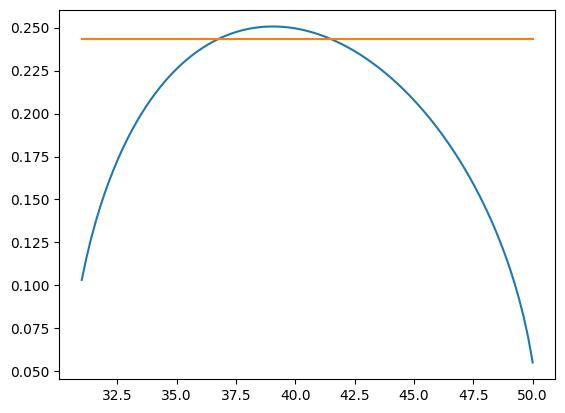

In [ ]:
a = ((15 - 10)**2 + (50 - 10)**2)**0.5
b = 40
c = 10
np.arccos((a**2 + b**2 - c**2) / (2 * a * b))
x = np.linspace(31, 50, 100)
y = np.arccos((a**2 + x**2 - c**2) / (2 * a * x))
plt.plot(x, y)
plt.plot(x, [0.2431608692238309]*len(x))
plt.show()

In [ ]:
# planet: id=0, owner=0, x=10, y=10, radius=5, ships=1, production=3
obs7 = Obs(
    planets=[
        [0, 0, 10.0, 10.0, 5.0, 10, 3],
        [1, -1, 30.0, 10.0, 5.0, 5, 1],
        [2, -1, 50.0, 15.0, 10.0, 1, 10],
    ],
    angular_velocity=0.0,
)
df7 = _simulate(copy.deepcopy(obs7), global_step=0, num_agents=2, n_steps=NB_STEPS_SIM)
print(df7)
action = [[0, 0.12435499454676144, 5]]
action = [[0, 0.3675158637705923, 5]]
action = [[0, 0.30, 9]]
action = [[0, np.arctan2(15 - 10, 50 - 10) + max(y), 5]]
action, possible_attacks = take_action(df7, player_id=0, nb_steps_sim=NB_STEPS_SIM, return_df=True)
print(f"\nAction: {action}")
snaps7 = simulate_with_action(copy.deepcopy(obs7), action, 25)
make_animation(snaps7, title='Test 7 — Planet Production (prod=3)', interval=400)

    step  id     x     y  radius  ships  production  owner  nature
0      0   0  10.0  10.0     5.0     10           3      0     fix
1      0   1  30.0  10.0     5.0      5           1     -1  moving
2      0   2  50.0  15.0    10.0      1          10     -1  moving
3      1   0  10.0  10.0     5.0     13           3      0     fix
4      1   1  30.0  10.0     5.0      5           1     -1  moving
..   ...  ..   ...   ...     ...    ...         ...    ...     ...
58    19   1  30.0  10.0     5.0      5           1     -1  moving
59    19   2  50.0  15.0    10.0      1          10     -1  moving
60    20   0  10.0  10.0     5.0     70           3      0     fix
61    20   1  30.0  10.0     5.0      5           1     -1  moving
62    20   2  50.0  15.0    10.0      1          10     -1  moving

[63 rows x 9 columns]
From 0, To 1 at step 5 with 6 ships (target has min 10)

Action: [[0.0, 0.0, 6.0]]


In [ ]:
player_id = 0

df_obstacles = IntervalProcessor.create_cumulative_obstacles(possible_attacks)

attacks_with_angle = (
    possible_attacks
    .merge(
        df_obstacles,
        how="left",
        on=["id_src", "step", "ships_sent"],
    )
    .assign(
        angle_list=lambda d: d.apply(IntervalProcessor.compute_free_angles, axis=1)
    )
    .query("angle_list.str.len() > 0")  # Only keep rows where there is at least some free angle
)

planet_id_top_5_id_src = (
    attacks_with_angle
    .sort_values(["step", "ships_sent"], ascending=True)
    .groupby(["id_src", "id"], as_index=False)
    .first()
    .groupby("id_src", as_index=False)
    .head(5)
    [["id_src", "id"]]
)

# attacks_with_angle_comets = attacks_with_angle.query("nature_src == 'comet'")  # Only consider attacking from fixed planets that produce ships, to avoid overcomplicating the angle tracking with moving planets or wasting attacks from non-producing ones
# if not attacks_with_angle_comets.empty and max(max((attacks_with_angle_comets["x_src"]-CENTER).abs()), max((attacks_with_angle_comets["y_src"]-CENTER).abs())) > 45:
#     moves = (
#         attacks_with_angle_comets
#         .sort_values("step", ascending=True)
#         .groupby("id_src", as_index=False)
#         .first()
#         [["id_src", "angle", "ships_sent"]]
#         .values
#         .tolist()
#     )
#     id_to_avoid = attacks_with_angle_comets["id_src"].unique().tolist() 
#     attacks_with_angle = attacks_with_angle.query("id_src not in @id_to_avoid")  # Remove the comet attack source from the main attack dataframe to avoid double attacking from it
    

attacks = (
    planet_id_top_5_id_src
    .merge(
        attacks_with_angle,
        how="left",
        on=["id_src", "id"]
    )
    # .query("id in @planet_top_5")  # Only consider attacking planets that are in the top 5 of at least one of our attack options
    .query("ships_sent <= ships_min")  # Ensure we have enough ships to attack
    .query("ships + production + 1 <= ships_sent and ships_sent <= ships + production + production_src + 1")  # Ensure we are looking at future steps CAN BE LATER REMOVED TO CONSIDER PAIR ATTACKS
    .query("@player_id != owner")
    .sort_values(["step", "ships_sent"], ascending=True)
    .groupby(["id_src", "id"], as_index=False)
    .first()
    .assign(
        time_cost=lambda d: d["ships"] / d["production_src"],
        total_time_cost=lambda d: d.groupby("id_src")["time_cost"].transform("sum"),
        score=lambda d: (d["total_time_cost"] - d["time_cost"]) * d["production"],
    )
    .sort_values("score", ascending=False)
    .query("ships_sent <= ships_min")  # Ensure we have enough ships to attack
    .groupby("id_src", as_index=False)
    .first()
    .assign(
        final_angle = lambda d: IntervalProcessor.interval_to_final_angle(d["angle_list"])
    )
)

In [ ]:
planet_id_top_5_id_src

,id_src,id
0,0,1
1,0,2


In [ ]:
attacks = (
    planet_id_top_5_id_src
    .merge(
        attacks_with_angle,
        how="left",
        on=["id_src", "id"]
    )
    # .query("id in @planet_top_5")  # Only consider attacking planets that are in the top 5 of at least one of our attack options
    .query("ships_sent <= ships_min")  # Ensure we have enough ships to attack
    # .query("ships + production + 1 <= ships_sent and ships_sent <= ships + production + production_src + 1")  # Ensure we are looking at future steps CAN BE LATER REMOVED TO CONSIDER PAIR ATTACKS
    # .query("@player_id != owner")
    # .sort_values(["step", "ships_sent"], ascending=True)
    # .groupby(["id_src", "id"], as_index=False)
    # .first()
    # .assign(
    #     time_cost=lambda d: d["ships"] / d["production_src"],
    #     total_time_cost=lambda d: d.groupby("id_src")["time_cost"].transform("sum"),
    #     score=lambda d: (d["total_time_cost"] - d["time_cost"]) * d["production"],
    # )
    # .sort_values("score", ascending=False)
    # .query("ships_sent <= ships_min")  # Ensure we have enough ships to attack
    # .groupby("id_src", as_index=False)
    # .first()
    # .assign(
    #     final_angle = lambda d: IntervalProcessor.interval_to_final_angle(d["angle_list"])
    # )
    .query("id==2")
)
attacks

,id_src,id,step_src,x_src,y_src,radius_src,ships_min,production_src,nature_src,row_count,...,dist_fleet_src_min,dist_fleet_src_max,collision,crossing_sun,angle,radius_angle,angle_min,angle_max,obstacle_list,angle_list
324,0,2,0,10.0,10.0,5.0,10,3,fix,21,...,30.609256,32.571506,True,False,0.124355,0.174973,6.232567,0.299328,"[(0.0, 0.2511893405532383), (6.031995966626348...","[(0.2511893405532383, 0.29932804003599567)]"
326,0,2,0,10.0,10.0,5.0,10,3,fix,21,...,29.760566,31.657532,True,False,0.124355,0.140394,6.267146,0.264749,"[(0.0, 0.24855578153105967), (6.03462952564852...","[(0.24855578153105967, 0.26474940113307044)]"
345,0,2,0,10.0,10.0,5.0,10,3,fix,21,...,32.571506,34.533757,True,False,0.124355,0.219198,6.188342,0.343553,"[(0.0, 0.29932804003599567), (6.03199596662634...","[(0.29932804003599567, 0.34355333827186146)]"
346,0,2,0,10.0,10.0,5.0,10,3,fix,21,...,31.657532,33.554499,True,False,0.124355,0.200782,6.206759,0.325137,"[(0.0, 0.26474940113307044), (6.03462952564852...","[(0.26474940113307044, 0.32513661965864143)]"
347,0,2,0,10.0,10.0,5.0,10,3,fix,21,...,30.661460,32.487279,True,False,0.124355,0.172305,6.235235,0.296660,"[(0.0, 0.25208732195357647), (6.03109798522601...","[(0.25208732195357647, 0.29666026012931757)]"
350,0,2,0,10.0,10.0,5.0,10,3,fix,21,...,33.554499,35.451465,True,False,0.124355,0.231706,6.175834,0.356061,"[(0.0, 0.32513661965864143), (6.03462952564852...","[(0.32513661965864143, 0.3560610329324666)]"
351,0,2,0,10.0,10.0,5.0,10,3,fix,21,...,34.533757,36.496007,True,False,0.124355,0.241580,6.165961,0.365935,"[(0.0, 0.34355333827186146), (6.03199596662634...","[(0.34355333827186146, 0.36593467675984703)]"
353,0,2,0,10.0,10.0,5.0,10,3,fix,21,...,31.313470,33.061035,True,False,0.124355,0.188938,6.218603,0.313293,"[(0.0, 0.25225600278572097), (6.03092930439386...","[(0.25225600278572097, 0.31329269485872974)]"
354,0,2,0,10.0,10.0,5.0,10,3,fix,21,...,32.487279,34.313098,True,False,0.124355,0.215557,6.191984,0.339912,"[(0.0, 0.29666026012931757), (6.03109798522601...","[(0.29666026012931757, 0.3399116526784569)]"
356,0,2,0,10.0,10.0,5.0,10,3,fix,21,...,30.007758,31.668276,True,False,0.124355,0.140890,6.266650,0.265245,"[(0.0, 0.2503647964142385), (6.032820510765347...","[(0.2503647964142385, 0.26524480816588014)]"


## Test 8 — Attacking Neutral
Player 0 (50 ships) vs neutral (5 ships) — overwhelming advantage → should attack.

In [ ]:
n_steps = 50
obs1 = Obs(
    planets=[[0, 0, 10.0, 10.0, 5.0, 50, 3], [1, -1, 30.0, 5.0, 5.0, 5, 2], [2, -1, 30.0, 50.0, 5.0, 5, 2]],
    angular_velocity=math.pi / 20,
)
df8 = _simulate(obs1, global_step=0, num_agents=2, n_steps=n_steps)
print(df8)  
action = take_action(df8, player_id=0, nb_steps_sim=n_steps)
print(f"\nAction: {action} (attack with overwhelming force)")
snaps8 = simulate_with_action(copy.deepcopy(obs1), action, n_steps)
make_animation(snaps8, title='Test 8 — Attacking Neutral', interval=200)

     step  id          x          y  radius  ships  production  owner  nature
0       0   0  10.000000  10.000000     5.0     50           3      0     fix
1       0   1  30.000000   5.000000     5.0      5           2     -1     fix
2       0   2  30.000000  50.000000     5.0      5           2     -1  moving
3       1   0  10.000000  10.000000     5.0     53           3      0     fix
4       1   1  30.000000   5.000000     5.0      5           2     -1     fix
..    ...  ..        ...        ...     ...    ...         ...    ...     ...
148    49   1  30.000000   5.000000     5.0      5           2     -1     fix
149    49   2  43.819660  30.978870     5.0      5           2     -1  moving
150    50   0  10.000000  10.000000     5.0    200           3      0     fix
151    50   1  30.000000   5.000000     5.0      5           2     -1     fix
152    50   2  46.871311  30.246233     5.0      5           2     -1  moving

[153 rows x 9 columns]
From 0, To 1 at step 5 with 8 ships (tar